Im folgenden Notebook werden Solar Flares vorhergesagt

Importiere Bibliotheken

In [1]:
## Basis Bibliotheken ##
import numpy as np
import pandas as pd
from pathlib import Path

## Visuelles ##
import seaborn as sns
import matplotlib.pyplot as plt

## Tools ##
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


## Pytorch Setup ##
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import math

## Seeds für Reproduzierbarkeit ##
torch.manual_seed(42)
np.random.seed(42)


### Daten laden
 Hier werden die Daten geladen. Nach einer ersten Übersicht wird die Spalte "Standford Solar Field (GOES15)" aussortiert, da in dieser nur über einen kleinen Zeitraum Werte existieren.

In [2]:
BASE_PATH = Path.cwd().parent
DATA_PATH = BASE_PATH / "Data"
output = BASE_PATH / "Output"


solar_data = pd.read_csv(DATA_PATH / "daily_solar_data.csv")
geomagnetic_data = pd.read_csv(DATA_PATH / "daily_geomagnetic_data.csv")

solar_data.drop(columns=['Stanford Mean Solar Field (GOES15)'], inplace=True)

In [3]:
solar_data.head()

,Date,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Stanford Background X-Ray Flux,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3
0,1997-01-01,72,0,0,0,A0.5,0,0,0,-1,-1,-1,-1
1,1997-01-02,72,0,0,0,A0.5,0,0,0,-1,-1,-1,-1
2,1997-01-03,73,0,0,0,A0.5,0,0,0,-1,-1,-1,-1
3,1997-01-04,74,13,10,1,A0.6,0,0,0,-1,-1,-1,-1
4,1997-01-05,74,15,20,0,A0.7,0,0,0,-1,-1,-1,-1


In [4]:
geomagnetic_data.head()

,Timestamp,Middle Latitude A,High Latitude A,Estimated A,Middle Latitude K,High Latitude K,Estimated K
0,1997-01-01 00:00:00.000000,4,*,2,1,*,1.0
1,1997-01-01 03:00:00.000000,4,*,2,1,*,1.0
2,1997-01-01 06:00:00.000000,4,*,2,1,*,0.0
3,1997-01-01 09:00:00.000000,4,*,2,1,*,0.0
4,1997-01-01 12:00:00.000000,4,*,2,1,*,0.0


### Daten bereinigen

In [5]:
solar_data.replace(['*', '-1', '-999'], np.nan, inplace=True)
solar_data.replace(-1, np.nan, inplace=True)
geomagnetic_data.replace(['*', '-1'], np.nan, inplace=True)
geomagnetic_data.replace(-1, np.nan, inplace=True)

,Timestamp,Middle Latitude A,High Latitude A,Estimated A,Middle Latitude K,High Latitude K,Estimated K
0,1997-01-01 00:00:00.000000,4.0,NaN,2,1.0,NaN,1.00
1,1997-01-01 03:00:00.000000,4.0,NaN,2,1.0,NaN,1.00
2,1997-01-01 06:00:00.000000,4.0,NaN,2,1.0,NaN,0.00
3,1997-01-01 09:00:00.000000,4.0,NaN,2,1.0,NaN,0.00
4,1997-01-01 12:00:00.000000,4.0,NaN,2,1.0,NaN,0.00
...,...,...,...,...,...,...,...
78667,2024-04-12 09:00:00.000000,6.0,3,7,2.0,1,1.67
78668,2024-04-12 12:00:00.000000,6.0,3,7,2.0,0,1.00
78669,2024-04-12 15:00:00.000000,6.0,3,7,2.0,1,1.00
78670,2024-04-12 18:00:00.000000,6.0,3,7,2.0,1,1.33


In [6]:
solar_data[['Radio Flux 10.7cm', 'Sunspot Number', 'Sunspot Area (10^6 Hemis.)', 'New Regions', 'Flares: C', 'Flares: M', 'Flares: X', 'Flares: S', 'Flares: 1', 'Flares: 2', 'Flares: 3']] = solar_data[['Radio Flux 10.7cm', 'Sunspot Number', 'Sunspot Area (10^6 Hemis.)', 'New Regions', 'Flares: C', 'Flares: M', 'Flares: X', 'Flares: S', 'Flares: 1', 'Flares: 2', 'Flares: 3']].astype(float, errors='raise')
solar_data.head()

,Date,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Stanford Background X-Ray Flux,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3
0,1997-01-01,72.0,0.0,0.0,0.0,A0.5,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,1997-01-02,72.0,0.0,0.0,0.0,A0.5,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,1997-01-03,73.0,0.0,0.0,0.0,A0.5,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,1997-01-04,74.0,13.0,10.0,1.0,A0.6,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,1997-01-05,74.0,15.0,20.0,0.0,A0.7,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [7]:
print ("size of CSV", solar_data.shape)

size of CSV (10330, 13)


In [8]:
geomagnetic_data[['Middle Latitude A', 'High Latitude A', 'Estimated A', 'Middle Latitude K', 'High Latitude K', 'Estimated K']] = geomagnetic_data[['Middle Latitude A', 'High Latitude A', 'Estimated A', 'Middle Latitude K', 'High Latitude K', 'Estimated K']].astype(float, errors='raise')
geomagnetic_data.head()

,Timestamp,Middle Latitude A,High Latitude A,Estimated A,Middle Latitude K,High Latitude K,Estimated K
0,1997-01-01 00:00:00.000000,4.0,NaN,2.0,1.0,NaN,1.0
1,1997-01-01 03:00:00.000000,4.0,NaN,2.0,1.0,NaN,1.0
2,1997-01-01 06:00:00.000000,4.0,NaN,2.0,1.0,NaN,0.0
3,1997-01-01 09:00:00.000000,4.0,NaN,2.0,1.0,NaN,0.0
4,1997-01-01 12:00:00.000000,4.0,NaN,2.0,1.0,NaN,0.0


In [9]:
print ("size of CSV", geomagnetic_data.shape)

size of CSV (78672, 7)


Beide Datensätze auf das gleiche Datenformat bringen

In [ ]:
geomagnetic_data['Timestamp'] = pd.to_datetime(geomagnetic_data['Timestamp'])
solar_data['Date'] = pd.to_datetime(solar_data['Date']).dt.date
geomagnetic_data['Date'] = geomagnetic_data['Timestamp'].dt.date

geo_cols = ['Middle Latitude A', 'High Latitude A', 'Estimated A',
            'Middle Latitude K', 'High Latitude K', 'Estimated K']

geomagnetic_daily = geomagnetic_data.groupby('Date')[geo_cols].agg(['mean', 'max', 'std'])
geomagnetic_daily.columns = [f'{col}_{stat}' for col, stat in geomagnetic_daily.columns]
geomagnetic_daily = geomagnetic_daily.reset_index()

geomagnetic_daily = geomagnetic_daily.fillna(0)

merged_data = pd.merge(solar_data, geomagnetic_daily, on='Date', how='inner')

print(f"Geomagnetic daily shape: {geomagnetic_daily.shape}")
print(f"Merged data shape: {merged_data.shape}")

Geomagnetic daily shape: (9380, 19)
Merged data shape: (9747, 31)


Hier wird das Feature "Standford Background X-ray Flux" zu einem numerischen Wert umgewandelt, um dieses Feature mit in das Training aufnehmen zu können

In [11]:
CLASS_MAP = {'A': 1e-8, 'B': 1e-7, 'C': 1e-6, 'M': 1e-5, 'X': 1e-4}

def parse_xray_class(val):
    if not isinstance(val, str):
        return float('nan')
    val = val.strip()
    letter = val[0].upper()
    if letter not in CLASS_MAP:
        return float('nan')
    try:
        return CLASS_MAP[letter] * float(val[1:])
    except ValueError:
        return float('nan')
    
merged_data['xray_flux_numeric'] = (merged_data['Stanford Background X-Ray Flux'].apply(parse_xray_class))

parsed_data = merged_data['xray_flux_numeric'].notna().sum()
parsed_nan = merged_data['xray_flux_numeric'].isna().sum()

print(f"Parsed {parsed_data} valid entries, {parsed_nan} NaN entries.")
print(f"Min: {merged_data['xray_flux_numeric'].min():.2e}, Max: {merged_data['xray_flux_numeric'].max():.2e}")
print(merged_data[['Stanford Background X-Ray Flux', 'xray_flux_numeric']].head(8))

Parsed 8365 valid entries, 1382 NaN entries.
Min: 0.00e+00, Max: 2.00e-05
  Stanford Background X-Ray Flux  xray_flux_numeric
0                           A0.5       5.000000e-09
1                           A0.5       5.000000e-09
2                           A0.5       5.000000e-09
3                           A0.6       6.000000e-09
4                           A0.7       7.000000e-09
5                           A1.0       1.000000e-08
6                           A0.8       8.000000e-09
7                           A0.8       8.000000e-09


In [12]:
null_counts = merged_data.isnull().sum()
print("Null values in merged dataset:")
print(null_counts)

Null values in merged dataset:
Date                                 0
Radio Flux 10.7cm                    0
Sunspot Number                       0
Sunspot Area (10^6 Hemis.)           0
New Regions                          0
Stanford Background X-Ray Flux    1378
Flares: C                            0
Flares: M                            0
Flares: X                            0
Flares: S                           90
Flares: 1                           90
Flares: 2                           90
Flares: 3                           90
Middle Latitude A_mean               0
Middle Latitude A_max                0
Middle Latitude A_std                0
High Latitude A_mean                 0
High Latitude A_max                  0
High Latitude A_std                  0
Estimated A_mean                     0
Estimated A_max                      0
Estimated A_std                      0
Middle Latitude K_mean               0
Middle Latitude K_max                0
Middle Latitude K_std            

In [13]:
print ("CSV-Größe merged Data:", merged_data.shape)
print (merged_data.info())

CSV-Größe merged Data: (9747, 32)
<class 'pandas.DataFrame'>
RangeIndex: 9747 entries, 0 to 9746
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            9747 non-null   object 
 1   Radio Flux 10.7cm               9747 non-null   float64
 2   Sunspot Number                  9747 non-null   float64
 3   Sunspot Area (10^6 Hemis.)      9747 non-null   float64
 4   New Regions                     9747 non-null   float64
 5   Stanford Background X-Ray Flux  8369 non-null   str    
 6   Flares: C                       9747 non-null   float64
 7   Flares: M                       9747 non-null   float64
 8   Flares: X                       9747 non-null   float64
 9   Flares: S                       9657 non-null   float64
 10  Flares: 1                       9657 non-null   float64
 11  Flares: 2                       9657 non-null   float64
 12  Flares: 3  

Alle Features aufführen

In [15]:
numeric_columns = ['Radio Flux 10.7cm',
                   'Sunspot Number',
                   'Sunspot Area (10^6 Hemis.)',
                   'New Regions',
                   'xray_flux_numeric',
                   'Flares: C', 'Flares: M', 'Flares: X',
                   'Flares: S', 'Flares: 1', 'Flares: 2', 'Flares: 3',
                   'Middle Latitude K_mean', 'Middle Latitude K_max', 'Middle Latitude K_std',
                   ]

Korrelationsmatrix erstellen, um Relevanz der Features zu ermitteln

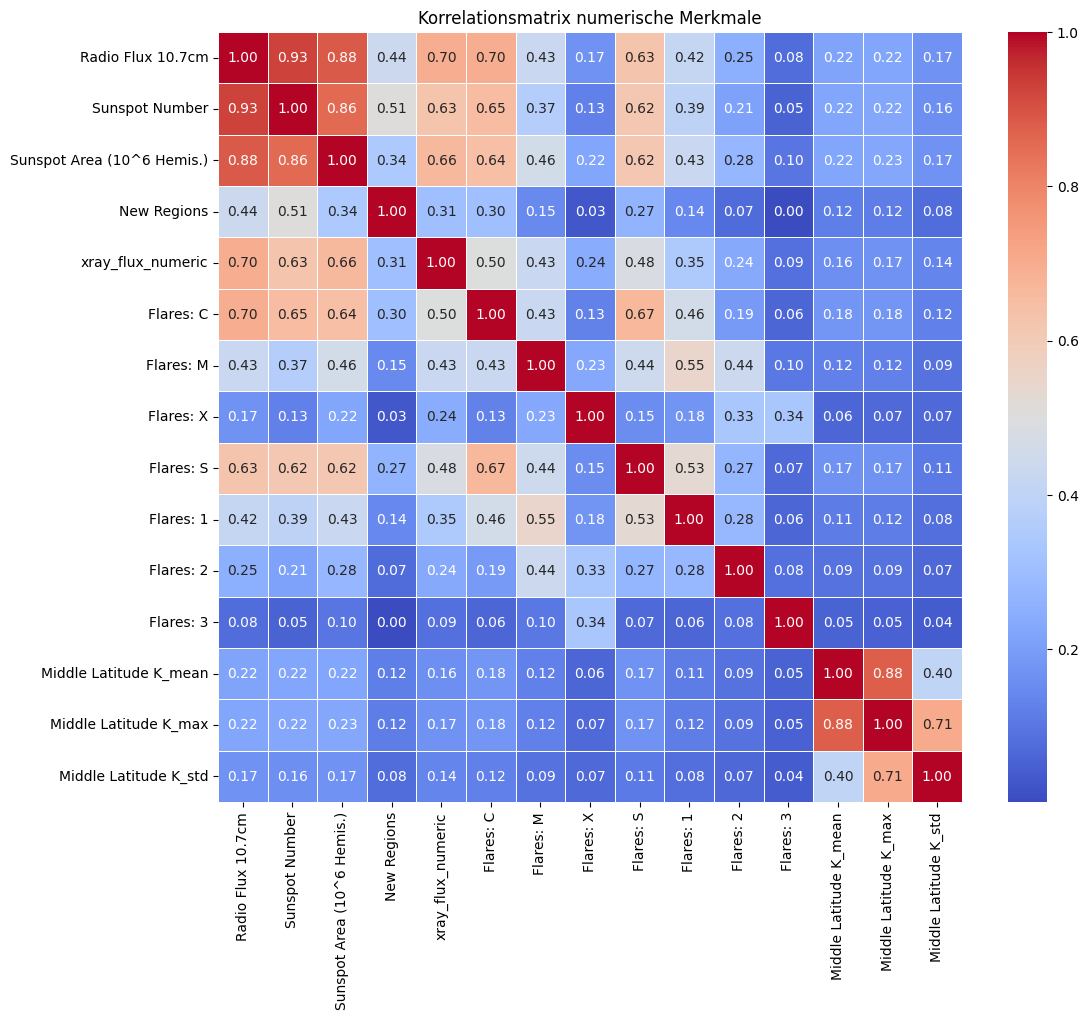

In [16]:
corr_matrix = merged_data[numeric_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title("Korrelationsmatrix numerische Merkmale")
plt.show()  

Daten bereinigen und entsprechend mit NaN füllen.
Dadurch, dass einige Features von Relevanz sind, aber nicht durchgehend aufgezeichnet wurden, bleibt das Feature bestehen. Die Lücken werden ausschließlich mit Forward-Fill gefüllt, um Data Leakage (Nutzung zukünftiger Werte) zu vermeiden.

In [17]:
merged_data.replace(['*', '-1', '-999'], np.nan, inplace=True)

numeric_merged_data = merged_data.select_dtypes(include=[np.number]).columns

# Nur Forward-Fill, um Data Leakage zu vermeiden (keine Nutzung zukünftiger Werte)
merged_data[numeric_merged_data] = merged_data[numeric_merged_data].interpolate(method='linear', limit_direction='forward')
merged_data = merged_data.ffill()

# Verbleibende NaN am Anfang der Zeitreihe mit dem ersten verfügbaren Wert füllen
merged_data = merged_data.bfill()

print(f"Verbleibende NaN: {merged_data.isnull().sum().sum()}")

merged_data[numeric_columns].head()

Verbleibende NaN: 0


,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,xray_flux_numeric,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3,Middle Latitude K_mean,Middle Latitude K_max,Middle Latitude K_std
0,72.0,0.0,0.0,0.0,5.000000e-09,0.0,0.0,0.0,5.0,1.0,0.0,0.0,1.125,2.0,0.353553
1,72.0,0.0,0.0,0.0,5.000000e-09,0.0,0.0,0.0,5.0,1.0,0.0,0.0,1.125,2.0,0.353553
2,73.0,0.0,0.0,0.0,5.000000e-09,0.0,0.0,0.0,5.0,1.0,0.0,0.0,1.125,2.0,0.353553
3,74.0,13.0,10.0,1.0,6.000000e-09,0.0,0.0,0.0,5.0,1.0,0.0,0.0,1.125,2.0,0.640870
4,74.0,15.0,20.0,0.0,7.000000e-09,0.0,0.0,0.0,5.0,1.0,0.0,0.0,1.125,2.0,0.353553


In [18]:
print ("CSV-Größe merged Data:", merged_data.shape)

CSV-Größe merged Data: (9747, 32)


Nur noch relevante Features werden berücksichtigt. Es wurde die Daten, die zu stark miteinander korreliert haben entfernt. Sowie die Ziel-Features "Flare: M" und "Flare: X", da diese binär vorhergesagt werden sollen. 

In [19]:
feature_columns = ['Radio Flux 10.7cm',
                   'Sunspot Number',
                   'New Regions',
                   'xray_flux_numeric',
                   'Flares: C',
                   'Middle Latitude K_std',
                   ]

Korrelationsmatrix der relevanten Features zur Übersicht

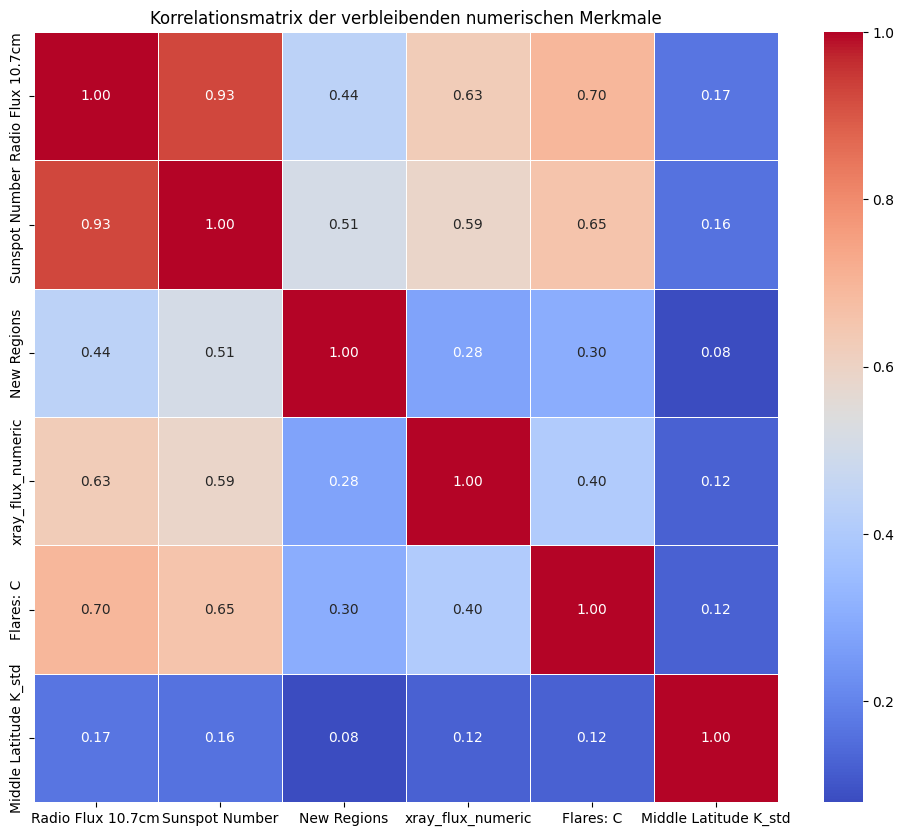

In [20]:
corr_matrix = merged_data[feature_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Korrelationsmatrix der verbleibenden numerischen Merkmale")
plt.show()  

Datenübersicht

In [21]:
null_counts = merged_data[feature_columns].isnull().sum()
print(null_counts)

Radio Flux 10.7cm        0
Sunspot Number           0
New Regions              0
xray_flux_numeric        0
Flares: C                0
Middle Latitude K_std    0
dtype: int64


Da die Sonne eine Aktivität innerhalb eines elf-jährgen Zyklus hat und dieses Anhand der Radio Flux Data gut zu überprüfen ist, wird hier der gesamte Verlauf von dem Datensatz (1997-2024) ausgegeben.

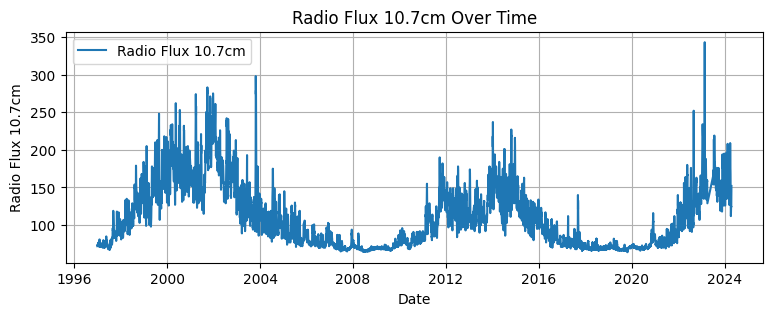

In [20]:
radio_flux = merged_data['Radio Flux 10.7cm']
plt.figure(figsize=(9, 3))
plt.plot(merged_data['Date'], radio_flux, label='Radio Flux 10.7cm')
plt.xlabel('Date')
plt.ylabel('Radio Flux 10.7cm')
plt.title('Radio Flux 10.7cm Over Time')
plt.legend()
plt.grid()
plt.show()

Erstelle Datensequenzen aus Rohdaten. 
Dabei sind "Flare: M" und "Flare: X" die Zielvariablen. Die Fenstergröße beträgt 7, da auf die sieben Tage vorherigen Tage geblickt wird. Damit lernt das Modell, dass sieben Tage gegeben sind und soll voraussagen "Gibt es an Tag 8 einen Flare - Ja/Nein."
Die Daten werden auf einen tägliche Mittelwert aggregiert, da in "daily_geomagentic_data" mehrere Zeilen pro Tag existieren.

In [22]:
def create_sequence_data(data, window_size=7, target_col='M_or_X'):

    daily_features = []

    for date in sorted(data['Date'].unique()):
        daily_data = data[data['Date'] == date]
        
        features = {'Date': date}

        for col in feature_columns:
            features[col] = daily_data[col].mean()

        # Prüfe auf M or X flares
        m_count = daily_data['Flares: M'].sum()
        x_count = daily_data['Flares: X'].sum()
        features['M_or_X'] = 1 if (m_count > 0 or x_count > 0) else 0

        daily_features.append(features)

    daily_data = pd.DataFrame(daily_features).sort_values('Date').reset_index(drop=True)

    updated_feature_columns = [col for col in daily_data.columns if col not in ['Date', target_col]]

    X, y = [], []

    # Erstelle Sequenzen
    for i in range(len(daily_data) - window_size):
        window = daily_data.iloc[i:i + window_size][updated_feature_columns].values
        X.append(window)

        target = daily_data.iloc[i + window_size][target_col]
        y.append(int(target))

    print(f"Features: {(len(updated_feature_columns))}: {updated_feature_columns}, \nFenster: {len(X)}")

    return np.array(X), np.array(y), updated_feature_columns

X, y, feature_columns = create_sequence_data(merged_data, window_size=7)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Anteil M oder X Flares: {y.sum() / len(y) * 100:.2f}%")

Features: 6: ['Radio Flux 10.7cm', 'Sunspot Number', 'New Regions', 'xray_flux_numeric', 'Flares: C', 'Middle Latitude K_std'], 
Fenster: 9286
X shape: (9286, 7, 6), y shape: (9286,)
Anteil M oder X Flares: 15.35%


Daten nach Aktivitätsgruppen sortieren

Die Sonne hat aktive und inaktive Phasen in einem 11-jährigen Zyklus. Um sicherzustellen, dass beim Train/Test-Split nicht nur nach y-Label gesplittet wird, sondern die Daten proportional verteilt sind, werden Aktivitätsgruppen gebildet. Dies verhindert, dass z.B. alle Flares zufällig im Trainingsset landen. 
Ein bedeutender Indikator der Aktivität ist der Radio Flux (vgl. Cell 32), weshalb dieser die Basis dür die Sortierung bietet. 

In [22]:
radio_flux_idx = feature_columns.index('Radio Flux 10.7cm')
activity_index = X[:, :, radio_flux_idx].mean(axis=1)

activity_groups = pd.Series(
    pd.cut(activity_index, bins=[0, 100, 150, np.inf], labels=['Low', 'Medium', 'High'])
)

combined_activity = activity_groups.astype(str) + '_' + pd.Series(y).astype(str)

print("Kombinierte Stratifizierungs-Klassen:")
print(combined_activity.value_counts().sort_index())

Kombinierte Stratifizierungs-Klassen:
High_0       884
High_1       626
Low_0       4786
Low_1        145
Medium_0    2191
Medium_1     654
Name: count, dtype: int64


### Trainings-, Validierungs - und Testdaten festelegen. 
Dabei ist die Verteilung wie folgt: Training: 80%, Validation: 20%, Test: 20%

In [ ]:
SPLIT_METHOD = "time"

if SPLIT_METHOD == "shuffle":
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_val_idx, test_idx = next(sss.split(X, combined_activity))

    X_train_val, X_test = X[train_val_idx], X[test_idx]
    y_train_val, y_test = y[train_val_idx], y[test_idx]
    activity_train_val = activity_groups.iloc[train_val_idx]
    activity_test = activity_groups.iloc[test_idx]
    combined_train_val = combined_activity.iloc[train_val_idx]

    # Train 75%, Validation 25%
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, val_idx = next(sss2.split(X_train_val, combined_train_val))

    X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
    y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]
    activity_train = activity_train_val.iloc[train_idx]
    activity_val = activity_train_val.iloc[val_idx]

elif SPLIT_METHOD == "time":
    train_end = int(len(X) * 0.6)
    val_end = int(len(X) * 0.8)

    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    activity_train = activity_groups.iloc[:train_end]
    activity_val = activity_groups.iloc[train_end:val_end]
    activity_test = activity_groups.iloc[val_end:]

# Verteilung der Klassen in den Splits anzeigen
print(f"Split-Methode: {SPLIT_METHOD}")
def print_split_distribution(name, X, y, activity_split):
    counts = activity_split.value_counts()
    n_flares = y.sum()
    rate = n_flares / len(y) * 100
    print(f'{name:<12} {len(X):<10} '
          f'{counts.get("Low", 0):<10} '
          f'{counts.get("Medium", 0):<10} '
          f'{counts.get("High", 0):<10} '
          f'{n_flares} ({rate:.1f}%)')
    
print(f'\n{"Split":<12} {"Samples":<10} {"Low":<10} {"Medium":<10} {"High":<10} {"M/X-Flares":<12}')
print_split_distribution('Train',      X_train, y_train, activity_train)
print_split_distribution('Validation', X_val,   y_val,   activity_val)
print_split_distribution('Test',       X_test,  y_test,  activity_test)

flare_rates = [y.sum() / len(y) * 100 for y in [y_train, y_val, y_test]]
if max(flare_rates) - min(flare_rates) > 1.5:
    print(f"\nFlare-Raten variieren stark zwischen den Splits")
    print(f"Ratio: {max(flare_rates) / min(flare_rates):.1f}x")
else:
    print("\nFlare-Raten sind ausgewogen zwischen den Splits.")

Split-Methode: time

Split        Samples    Low        Medium     High       M/X-Flares  
Train        5571       2786       1755       1030       916 (16.4%)
Validation   1857       989        672        196        230 (12.4%)
Test         1858       1156       418        284        279 (15.0%)

Flare-Raten variieren stark zwischen den Splits
Ratio: 1.3x


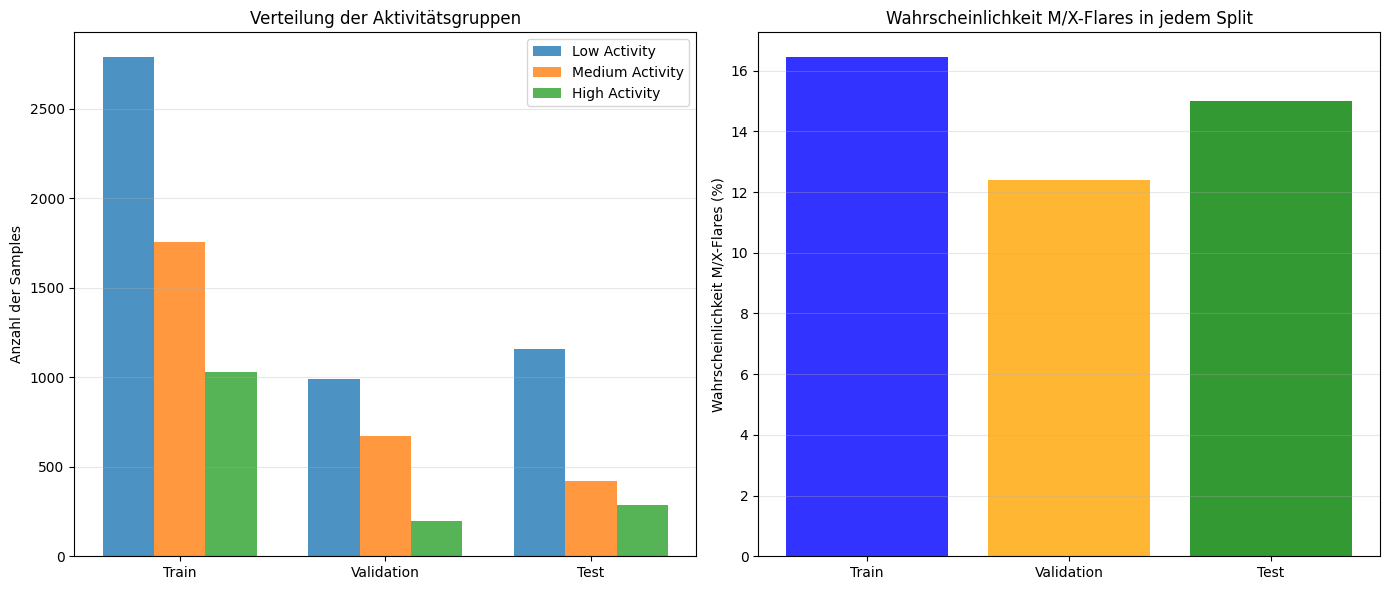

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

splits = ['Train', 'Validation', 'Test']
low_counts = [activity_train.value_counts().get('Low', 0),
              activity_val.value_counts().get('Low', 0),
              activity_test.value_counts().get('Low', 0)]
medium_counts = [activity_train.value_counts().get('Medium', 0),
                 activity_val.value_counts().get('Medium', 0),
                 activity_test.value_counts().get('Medium', 0)]
high_counts = [activity_train.value_counts().get('High', 0),
               activity_val.value_counts().get('High', 0),
               activity_test.value_counts().get('High', 0)]

x = np.arange(len(splits))
width = 0.25

axes[0].bar(x - width, low_counts, width, label='Low Activity', alpha=0.8)
axes[0].bar(x, medium_counts, width, label='Medium Activity', alpha=0.8)
axes[0].bar(x + width, high_counts, width, label='High Activity', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_title('Verteilung der Aktivitätsgruppen')
axes[0].set_ylabel('Anzahl der Samples')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


mxflares_rates = [y_train.sum() / len(y_train) * 100,
                 y_val.sum() / len(y_val) * 100,
                 y_test.sum() / len(y_test) * 100]
axes[1].bar(splits, mxflares_rates, color=['blue', 'orange', 'green'], alpha=0.8)
axes[1].set_title('Wahrscheinlichkeit M/X-Flares in jedem Split')
axes[1].set_ylabel('Wahrscheinlichkeit M/X-Flares (%)')
axes[1].grid(axis='y', alpha=0.3) 

plt.tight_layout()
plt.show()

Berechne class weights

In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(weights, dtype=torch.float32)
pos_weight = class_weights[1] / class_weights[0]

POS_WEIGHT_MULTIPLIER = 3.0
pos_weight = pos_weight * POS_WEIGHT_MULTIPLIER

print(f"Klasse 0 (kein Flare): {weights[0]:.3f}")
print(f"Klasse 1 (Flare):      {weights[1]:.3f}")
print(f"pos_weight: {pos_weight:.3f} (Multiplikator: {POS_WEIGHT_MULTIPLIER})")
print(f"Flare-Anteil in Train: {y_train.sum() / len(y_train) * 100:.1f}%")

Klasse 0 (kein Flare): 0.598
Klasse 1 (Flare):      3.041
pos_weight für BCELoss: 15.246 (Multiplikator: 3.0)
Flare-Anteil in Train: 16.4%


### Normalisiere Daten

Durch starke Ausreißer wird hier RobustScaler verwendet. 

In [26]:
n_train, timesteps, n_features = X_train.shape

# Reshape 3D to 2D
X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

scaler = RobustScaler()
X_train_2d = scaler.fit_transform(X_train_2d)
X_val_2d = scaler.transform(X_val_2d)
X_test_2d = scaler.transform(X_test_2d)

X_train = X_train_2d.reshape(n_train, timesteps, n_features)
X_val = X_val_2d.reshape(-1, timesteps, n_features)
X_test = X_test_2d.reshape(-1, timesteps, n_features)

print(f" Train: min={X_train.min():.1f}, max={X_train.max():.1f}")
print(f" Val:   min={X_val.min():.1f},   max={X_val.max():.1f}")
print(f" Test:  min={X_test.min():.1f},  max={X_test.max():.1f}")
print(f"Mittelwert Train (sollte ~0 sein): {X_train.mean():.4f}")
print(f"Std Train (sollte ~1 sein):        {X_train.std():.4f}")

 Train: min=-1.1, max=41.3
 Val:   min=-1.0,   max=5.0
 Test:  min=-1.1,  max=7.2
Mittelwert Train (sollte ~0 sein): 0.3163
Std Train (sollte ~1 sein):        0.9476


In [ ]:
HIDDEN_SIZE = 64
NUM_LAYERS = 3
DROPOUT = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10 

### PyTorch Setup

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# Dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataloader erstellt (batch_size={BATCH_SIZE})")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

batch_X, batch_y = next(iter(train_loader))
print(f"Batch X shape: {batch_X.shape}")
print(f"Batch y shape: {batch_y.shape}")
print(f"Dtype X: {batch_X.dtype}, y: {batch_y.dtype}")

Using device: cpu

Dataloader erstellt (batch_size=32)
Train batches: 175
Val batches:   59
Test batches:  59
Batch X shape: torch.Size([32, 7, 6])
Batch y shape: torch.Size([32])
Dtype X: torch.float32, y: torch.float32


### Modell-Parameter

### LSTM Modell

In [ ]:
class SolarFlareLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(SolarFlareLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.batch_norm = nn.BatchNorm1d(hidden_size)

        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]

        x = self.batch_norm(last_hidden)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x.squeeze(1)

### Focal Loss
Focal Loss fokussiert das Training auf schwer klassifizierbare Beispiele. In Kombination mit `pos_weight` soll das Modell stärker für verpasste Flares (False Negatives) bestraft werden.

In [30]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()

### Model initialisieren

In [31]:
input_size = X_train.shape[2]
model = SolarFlareLSTM(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
criterion = FocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_weight.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Training

In [ ]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_predicted = []
    all_labels = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        all_predicted.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * np.mean(np.array(all_predicted) == np.array(all_labels))
    recall = recall_score(all_labels, all_predicted, zero_division=0)
    f1 = f1_score(all_labels, all_predicted, zero_division=0)

    return epoch_loss, accuracy, recall, f1

In [34]:
def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predicted = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(val_loader)
    accuracy = 100 * np.mean(np.array(all_predicted) == np.array(all_labels))
    recall = recall_score(all_labels, all_predicted, zero_division=0)
    f1 = f1_score(all_labels, all_predicted, zero_division=0)

    return epoch_loss, accuracy, recall, f1, np.array(all_labels), np.array(all_predicted)

In [ ]:
print(f"Starte Training ({EPOCHS} Epochen, FocalLoss + Early Stopping)")

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_recalls, val_recalls = [], []
train_f1s, val_f1s = [], []

best_val_loss = float('inf')
best_model_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):

    train_loss, train_acc, train_recall, train_f1 = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)

    val_loss, val_acc, val_recall, val_f1, val_labels, val_preds = validate_model(
        model,
        val_loader,
        criterion,
        device
    )
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.1f}%, Recall: {train_recall:.3f}, F1: {train_f1:.3f}")
        print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.1f}%, Recall: {val_recall:.3f}, F1: {val_f1:.3f}")
        print(f"  Best Val Loss: {best_val_loss:.4f} (Epoch {best_epoch}), Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping bei Epoch {epoch+1} (keine Verbesserung seit {PATIENCE} Epochen)")
        break

model.load_state_dict(best_model_state)
print(f"\nTraining abgeschlossen. Beste Val Loss: {best_val_loss:.4f} (Epoch {best_epoch})")
print(f"Modell auf beste Gewichte zurückgesetzt.")

Starte Training (100 Epochen, FocalLoss + Early Stopping)
Epoch [  1/100]
  Train Loss: 0.4959, Acc: 54.9%, Recall: 0.748, F1: 0.353
  Val   Loss: 0.6144, Acc: 19.6%, Recall: 0.961, F1: 0.228
  Best Val Loss: 0.6144 (Epoch 1), Patience: 0/10
Epoch [ 10/100]
  Train Loss: 0.3447, Acc: 65.1%, Recall: 0.937, F1: 0.469
  Val   Loss: 0.2858, Acc: 64.9%, Recall: 0.943, F1: 0.400
  Best Val Loss: 0.2858 (Epoch 10), Patience: 0/10
Epoch [ 20/100]
  Train Loss: 0.3146, Acc: 66.3%, Recall: 0.940, F1: 0.478
  Val   Loss: 0.2931, Acc: 67.4%, Recall: 0.922, F1: 0.412
  Best Val Loss: 0.2811 (Epoch 16), Patience: 4/10

Early Stopping bei Epoch 26 (keine Verbesserung seit 10 Epochen)

Training abgeschlossen. Beste Val Loss: 0.2811 (Epoch 16)
Modell auf beste Gewichte zurückgesetzt.


### Test-Evaluation

### Threshold-Optimierung auf dem Validierungsset
Der optimale Schwellenwert wird auf dem Validierungsset bestimmt, indem der TSS (True Skill Statistic) maximiert wird.

Optimaler Schwellenwert (max TSS auf Validierung): 0.57
Bester TSS auf Validierungsset: 0.5967


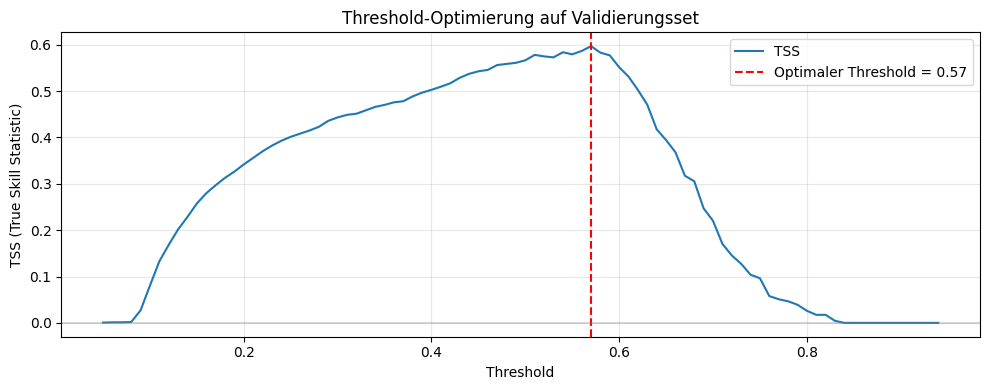

In [ ]:
model.eval()
val_probs = []
val_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        logits = model(batch_X)
        probs = torch.sigmoid(logits)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(batch_y.cpu().numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

thresholds = np.arange(0.05, 0.95, 0.01)
tss_scores = []

for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    cm_t = confusion_matrix(val_labels, preds_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    tss_t = recall_t - fpr_t
    tss_scores.append(tss_t)

tss_scores = np.array(tss_scores)
best_idx = np.argmax(tss_scores)
best_threshold = thresholds[best_idx]
best_tss_val = tss_scores[best_idx]

print(f"Optimaler Schwellenwert (max TSS auf Validierung): {best_threshold:.2f}")
print(f"Bester TSS auf Validierungsset: {best_tss_val:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(thresholds, tss_scores, label='TSS')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimaler Threshold = {best_threshold:.2f}')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Threshold')
plt.ylabel('TSS (True Skill Statistic)')
plt.title('Threshold-Optimierung auf Validierungsset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Classification Report (Test, Threshold=0.57) ===

                precision    recall  f1-score   support

Kein Flare (0)       0.89      0.92      0.91      1579
 M/X Flare (1)       0.47      0.38      0.42       279

      accuracy                           0.84      1858
     macro avg       0.68      0.65      0.67      1858
  weighted avg       0.83      0.84      0.84      1858

Precision:   0.4714
Recall:      0.3835
F1:          0.4229
Specificity: 0.9240
ROC-AUC:     0.8661
TSS:         0.3075
HSS:         0.3331
Threshold:   0.57


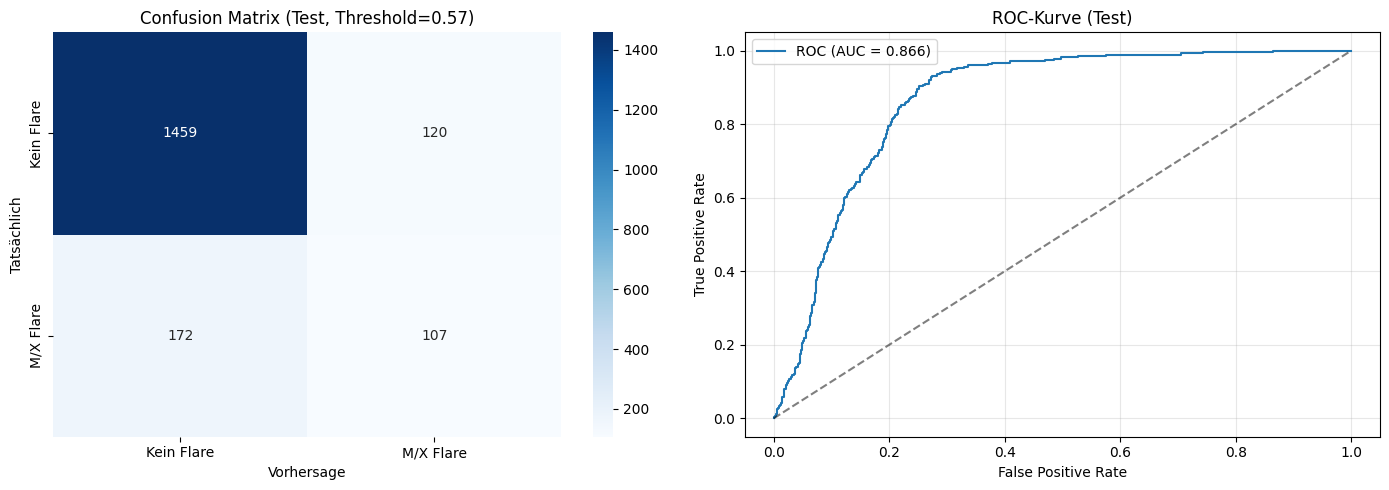

In [ ]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X)
        probs = torch.sigmoid(logits)
        preds = (probs >= best_threshold).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(f"=== Classification Report (Test, Threshold={best_threshold:.2f}) ===\n")
print(classification_report(all_labels, all_preds, target_names=['Kein Flare (0)', 'M/X Flare (1)']))

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

recall = recall_score(all_labels, all_preds)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

tss = tp / (tp + fn) - fp / (fp + tn)
hss = 2 * (tp * tn - fn * fp) / ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))

print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1:          {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"TSS:         {tss:.4f}")
print(f"HSS:         {hss:.4f}")
print(f"Threshold:   {best_threshold:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'], ax=axes[0])
axes[0].set_xlabel('Vorhersage')
axes[0].set_ylabel('Tatsächlich')
axes[0].set_title(f'Confusion Matrix (Test, Threshold={best_threshold:.2f})')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-Kurve (Test)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Loss-Kurve

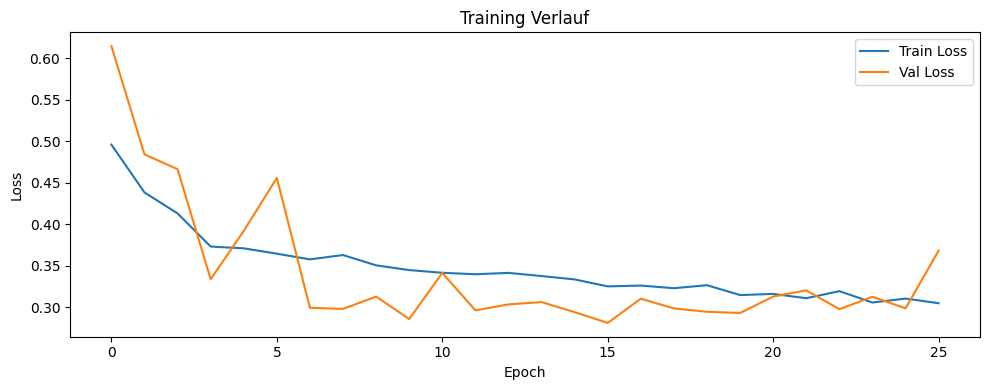

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Verlauf')
plt.legend()
plt.tight_layout()
plt.show()

GRU Modell für M/X-Flare vorhersage

In [ ]:
class SolarFlareGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(SolarFlareGRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.batch_norm = nn.BatchNorm1d(hidden_size)

        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_hidden = gru_out[:, -1, :]

        x = self.batch_norm(last_hidden)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x.squeeze(1)


In [ ]:
print("Initialisiere GRU Modell")

gru_model = SolarFlareGRU(
    input_size=input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

lstm_params = sum(p.numel() for p in model.parameters())
gru_params = sum(p.numel() for p in gru_model.parameters())

print(f"Modell auf {device}.")
print(f"Modellarchitektur:")
print(f"  Input Size:    {input_size}")
print(f"  Hidden Size:   {HIDDEN_SIZE}")
print(f"  Num Layers:    {NUM_LAYERS}")
print(f"  GRU Parameter: {gru_params:,}")
print(f"  LSTM Parameter: {lstm_params:,}")
print(f"  Differenz:     {lstm_params - gru_params:,} weniger Parameter im GRU ({(1 - gru_params/lstm_params)*100:.1f}%)")

gru_criterion = FocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_weight.to(device))
gru_optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

Initialisiere GRU Modell
Modell auf cpu.
Modellarchitektur:
  Input Size:    6
  Hidden Size:   64
  Num Layers:    3
  GRU Parameter: 68,097
  LSTM Parameter: 89,345
  Differenz:     21,248 weniger Parameter im GRU (23.8%)


In [ ]:
print(f"Starte GRU Training ({EPOCHS} Epochen, FocalLoss + Early Stopping)")

gru_train_losses, gru_val_losses = [], []
gru_train_accuracies, gru_val_accuracies = [], []
gru_train_recalls, gru_val_recalls = [], []
gru_train_f1s, gru_val_f1s = [], []

gru_best_val_loss = float('inf')
gru_best_model_state = None
gru_best_epoch = 0
gru_patience_counter = 0

for epoch in range(EPOCHS):

    train_loss, train_acc, train_recall, train_f1 = train_model(
        gru_model,
        train_loader,
        gru_criterion,
        gru_optimizer,
        device,
    )
    gru_train_losses.append(train_loss)
    gru_train_accuracies.append(train_acc)
    gru_train_recalls.append(train_recall)
    gru_train_f1s.append(train_f1)

    val_loss, val_acc, val_recall, val_f1, val_labels, val_preds = validate_model(
        gru_model,
        val_loader,
        gru_criterion,
        device
    )
    gru_val_losses.append(val_loss)
    gru_val_accuracies.append(val_acc)
    gru_val_recalls.append(val_recall)
    gru_val_f1s.append(val_f1)

    if val_loss < gru_best_val_loss:
        gru_best_val_loss = val_loss
        gru_best_epoch = epoch + 1
        gru_best_model_state = copy.deepcopy(gru_model.state_dict())
        gru_patience_counter = 0
    else:
        gru_patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.1f}%, Recall: {train_recall:.3f}, F1: {train_f1:.3f}")
        print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.1f}%, Recall: {val_recall:.3f}, F1: {val_f1:.3f}")
        print(f"  Best Val Loss: {gru_best_val_loss:.4f} (Epoch {gru_best_epoch}), Patience: {gru_patience_counter}/{PATIENCE}")

    if gru_patience_counter >= PATIENCE:
        print(f"\nEarly Stopping bei Epoch {epoch+1} (keine Verbesserung seit {PATIENCE} Epochen)")
        break

gru_model.load_state_dict(gru_best_model_state)
print(f"\nGRU Training abgeschlossen. Beste Val Loss: {gru_best_val_loss:.4f} (Epoch {gru_best_epoch})")
print(f"Modell auf beste Gewichte zurückgesetzt.")

Starte GRU Training (100 Epochen, FocalLoss + Early Stopping)
Epoch [  1/100]
  Train Loss: 0.5143, Acc: 53.5%, Recall: 0.771, F1: 0.353
  Val   Loss: 0.4294, Acc: 24.4%, Recall: 0.926, F1: 0.233
  Best Val Loss: 0.4294 (Epoch 1), Patience: 0/10
Epoch [ 10/100]
  Train Loss: 0.3381, Acc: 65.9%, Recall: 0.932, F1: 0.474
  Val   Loss: 0.3646, Acc: 48.6%, Recall: 0.957, F1: 0.315
  Best Val Loss: 0.3530 (Epoch 7), Patience: 3/10
Epoch [ 20/100]
  Train Loss: 0.3076, Acc: 67.4%, Recall: 0.943, F1: 0.488
  Val   Loss: 0.3247, Acc: 60.6%, Recall: 0.939, F1: 0.371
  Best Val Loss: 0.2895 (Epoch 16), Patience: 4/10

Early Stopping bei Epoch 26 (keine Verbesserung seit 10 Epochen)

GRU Training abgeschlossen. Beste Val Loss: 0.2895 (Epoch 16)
Modell auf beste Gewichte zurückgesetzt.


In [ ]:
gru_model.eval()
gru_val_probs = []
gru_val_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        logits = gru_model(batch_X)
        probs = torch.sigmoid(logits)
        gru_val_probs.extend(probs.cpu().numpy())
        gru_val_labels.extend(batch_y.cpu().numpy())

gru_val_probs = np.array(gru_val_probs)
gru_val_labels = np.array(gru_val_labels)

gru_thresholds = np.arange(0.05, 0.95, 0.01)
gru_tss_scores = []

for t in gru_thresholds:
    preds_t = (gru_val_probs >= t).astype(int)
    cm_t = confusion_matrix(gru_val_labels, preds_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    tss_t = recall_t - fpr_t
    gru_tss_scores.append(tss_t)

gru_tss_scores = np.array(gru_tss_scores)
gru_best_idx = np.argmax(gru_tss_scores)
gru_best_threshold = gru_thresholds[gru_best_idx]
gru_best_tss_val = gru_tss_scores[gru_best_idx]

print(f"GRU Optimaler Schwellenwert (max TSS auf Validierung): {gru_best_threshold:.2f}")
print(f"GRU Bester TSS auf Validierungsset: {gru_best_tss_val:.4f}")

# GRU Test-Evaluation
gru_all_preds = []
gru_all_probs = []
gru_all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = gru_model(batch_X)
        probs = torch.sigmoid(logits)
        preds = (probs >= gru_best_threshold).float()

        gru_all_probs.extend(probs.cpu().numpy())
        gru_all_preds.extend(preds.cpu().numpy())
        gru_all_labels.extend(batch_y.cpu().numpy())

gru_all_preds = np.array(gru_all_preds)
gru_all_probs = np.array(gru_all_probs)
gru_all_labels = np.array(gru_all_labels)

print(f"\n=== GRU Classification Report (Test, Threshold={gru_best_threshold:.2f}) ===\n")
print(classification_report(gru_all_labels, gru_all_preds, target_names=['Kein Flare (0)', 'M/X Flare (1)']))

gru_cm = confusion_matrix(gru_all_labels, gru_all_preds)
gru_tn, gru_fp, gru_fn, gru_tp = gru_cm.ravel()

gru_recall = recall_score(gru_all_labels, gru_all_preds)
gru_precision = gru_tp / (gru_tp + gru_fp) if (gru_tp + gru_fp) > 0 else 0
gru_f1 = f1_score(gru_all_labels, gru_all_preds)
gru_roc_auc = roc_auc_score(gru_all_labels, gru_all_probs)
gru_specificity = gru_tn / (gru_tn + gru_fp) if (gru_tn + gru_fp) > 0 else 0

gru_tss = gru_tp / (gru_tp + gru_fn) - gru_fp / (gru_fp + gru_tn)
gru_hss = 2 * (gru_tp * gru_tn - gru_fn * gru_fp) / ((gru_tp + gru_fn) * (gru_fn + gru_tn) + (gru_tp + gru_fp) * (gru_fp + gru_tn))

print(f"Precision:   {gru_precision:.4f}")
print(f"Recall:      {gru_recall:.4f}")
print(f"F1:          {gru_f1:.4f}")
print(f"Specificity: {gru_specificity:.4f}")
print(f"ROC-AUC:     {gru_roc_auc:.4f}")
print(f"TSS:         {gru_tss:.4f}")
print(f"HSS:         {gru_hss:.4f}")
print(f"Threshold:   {gru_best_threshold:.2f}")

GRU Optimaler Schwellenwert (max TSS auf Validierung): 0.63
GRU Bester TSS auf Validierungsset: 0.6288

=== GRU Classification Report (Test, Threshold=0.63) ===

                precision    recall  f1-score   support

Kein Flare (0)       0.88      0.96      0.92      1579
 M/X Flare (1)       0.51      0.23      0.32       279

      accuracy                           0.85      1858
     macro avg       0.69      0.60      0.62      1858
  weighted avg       0.82      0.85      0.83      1858

Precision:   0.5118
Recall:      0.2330
F1:          0.3202
Specificity: 0.9607
ROC-AUC:     0.8160
TSS:         0.1937
HSS:         0.2497
Threshold:   0.63


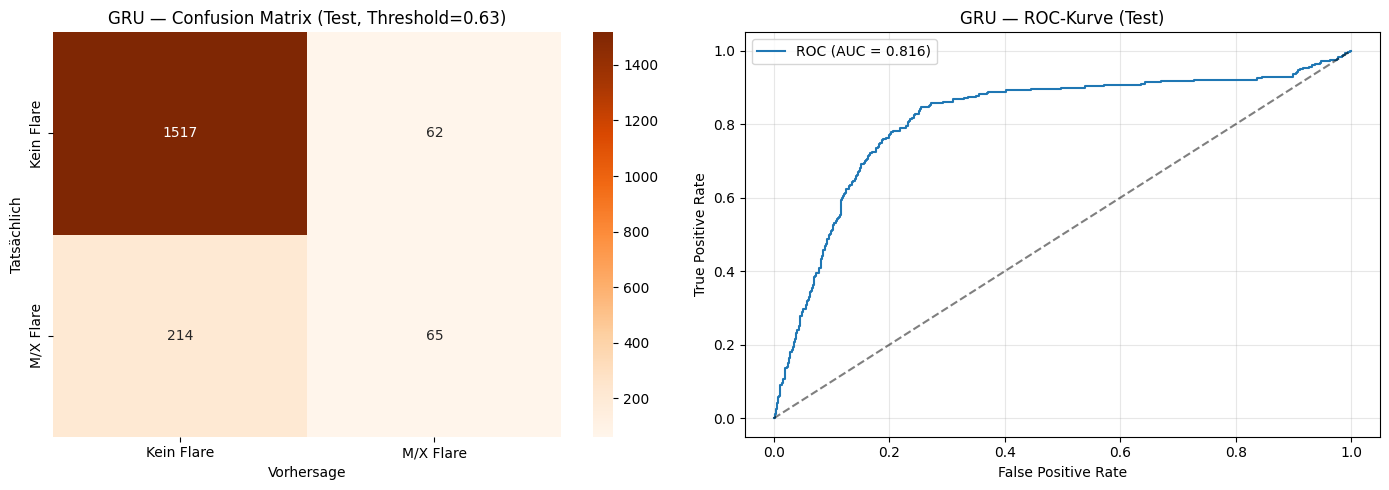

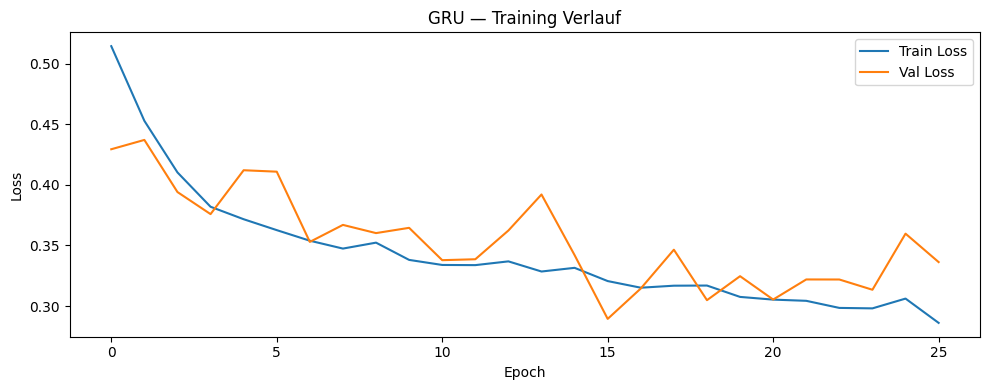

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(gru_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'], ax=axes[0])
axes[0].set_xlabel('Vorhersage')
axes[0].set_ylabel('Tatsächlich')
axes[0].set_title(f'GRU — Confusion Matrix (Test, Threshold={gru_best_threshold:.2f})')

gru_fpr, gru_tpr, _ = roc_curve(gru_all_labels, gru_all_probs)
axes[1].plot(gru_fpr, gru_tpr, label=f'ROC (AUC = {gru_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('GRU — ROC-Kurve (Test)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gru_train_losses, label='Train Loss')
plt.plot(gru_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU — Training Verlauf')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class SolarFlareTransformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, dropout):
        super(SolarFlareTransformer, self).__init__()

        self.input_projection = nn.Linear(input_size, d_model)

        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.batch_norm = nn.BatchNorm1d(d_model)

        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout_layer = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.input_projection(x)

        x = self.pos_encoder(x)

        x = self.transformer_encoder(x)

        x = x[:, -1, :]

        x = self.batch_norm(x)
        x = self.relu(self.fc1(x))
        x = self.dropout_layer(x)
        x = self.fc2(x)

        return x.squeeze(1)

In [ ]:
print("Initialisiere Transformer Modell")

d_model = 128
nhead = 8
transformer_num_layers = 3
dim_feedforward = 256
transformer_dropout = DROPOUT

transformer_model = SolarFlareTransformer(
    input_size=input_size,
    d_model=d_model,
    nhead=nhead,
    num_layers=transformer_num_layers,
    dim_feedforward=dim_feedforward,
    dropout=transformer_dropout
).to(device)

transformer_params = sum(p.numel() for p in transformer_model.parameters())
lstm_params = sum(p.numel() for p in model.parameters())
gru_params = sum(p.numel() for p in gru_model.parameters())

print(f"Modell auf {device}.")
print(f"Modellarchitektur:")
print(f"  Input Size:        {input_size}")
print(f"  d_model:           {d_model}")
print(f"  Attention Heads:   {nhead}")
print(f"  Encoder Layers:    {transformer_num_layers}")
print(f"  FFN Dim:           {dim_feedforward}")
print(f"  Transformer Param: {transformer_params:,}")
print(f"  LSTM Parameter:    {lstm_params:,}")
print(f"  GRU Parameter:     {gru_params:,}")

transformer_criterion = FocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_weight.to(device))
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)

Initialisiere Transformer Modell
Modell auf cpu.
Modellarchitektur:
  Input Size:        6
  d_model:           128
  Attention Heads:   8
  Encoder Layers:    3
  FFN Dim:           256
  Transformer Param: 406,913
  LSTM Parameter:    89,345
  GRU Parameter:     68,097


In [ ]:
print(f"Starte Transformer Training ({EPOCHS} Epochen, FocalLoss + Early Stopping)")

tf_train_losses, tf_val_losses = [], []
tf_train_accuracies, tf_val_accuracies = [], []
tf_train_recalls, tf_val_recalls = [], []
tf_train_f1s, tf_val_f1s = [], []

tf_best_val_loss = float('inf')
tf_best_model_state = None
tf_best_epoch = 0
tf_patience_counter = 0

for epoch in range(EPOCHS):

    train_loss, train_acc, train_recall, train_f1 = train_model(
        transformer_model,
        train_loader,
        transformer_criterion,
        transformer_optimizer,
        device,
    )
    tf_train_losses.append(train_loss)
    tf_train_accuracies.append(train_acc)
    tf_train_recalls.append(train_recall)
    tf_train_f1s.append(train_f1)

    val_loss, val_acc, val_recall, val_f1, val_labels, val_preds = validate_model(
        transformer_model,
        val_loader,
        transformer_criterion,
        device
    )
    tf_val_losses.append(val_loss)
    tf_val_accuracies.append(val_acc)
    tf_val_recalls.append(val_recall)
    tf_val_f1s.append(val_f1)

    if val_loss < tf_best_val_loss:
        tf_best_val_loss = val_loss
        tf_best_epoch = epoch + 1
        tf_best_model_state = copy.deepcopy(transformer_model.state_dict())
        tf_patience_counter = 0
    else:
        tf_patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.1f}%, Recall: {train_recall:.3f}, F1: {train_f1:.3f}")
        print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.1f}%, Recall: {val_recall:.3f}, F1: {val_f1:.3f}")
        print(f"  Best Val Loss: {tf_best_val_loss:.4f} (Epoch {tf_best_epoch}), Patience: {tf_patience_counter}/{PATIENCE}")

    if tf_patience_counter >= PATIENCE:
        print(f"\nEarly Stopping bei Epoch {epoch+1} (keine Verbesserung seit {PATIENCE} Epochen)")
        break

transformer_model.load_state_dict(tf_best_model_state)
print(f"\nTransformer Training abgeschlossen. Beste Val Loss: {tf_best_val_loss:.4f} (Epoch {tf_best_epoch})")
print(f"Modell auf beste Gewichte zurückgesetzt.")

Starte Transformer Training (100 Epochen, FocalLoss + Early Stopping)
Epoch [  1/100]
  Train Loss: 0.4927, Acc: 51.9%, Recall: 0.793, F1: 0.351
  Val   Loss: 0.2687, Acc: 66.6%, Recall: 0.965, F1: 0.417
  Best Val Loss: 0.2687 (Epoch 1), Patience: 0/10
Epoch [ 10/100]
  Train Loss: 0.4768, Acc: 57.9%, Recall: 0.886, F1: 0.409
  Val   Loss: 0.4498, Acc: 15.1%, Recall: 0.996, F1: 0.225
  Best Val Loss: 0.2687 (Epoch 1), Patience: 9/10

Early Stopping bei Epoch 11 (keine Verbesserung seit 10 Epochen)

Transformer Training abgeschlossen. Beste Val Loss: 0.2687 (Epoch 1)
Modell auf beste Gewichte zurückgesetzt.


In [ ]:
transformer_model.eval()
tf_val_probs = []
tf_val_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        logits = transformer_model(batch_X)
        probs = torch.sigmoid(logits)
        tf_val_probs.extend(probs.cpu().numpy())
        tf_val_labels.extend(batch_y.cpu().numpy())

tf_val_probs = np.array(tf_val_probs)
tf_val_labels = np.array(tf_val_labels)

tf_thresholds = np.arange(0.05, 0.95, 0.01)
tf_tss_scores = []

for t in tf_thresholds:
    preds_t = (tf_val_probs >= t).astype(int)
    cm_t = confusion_matrix(tf_val_labels, preds_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    tss_t = recall_t - fpr_t
    tf_tss_scores.append(tss_t)

tf_tss_scores = np.array(tf_tss_scores)
tf_best_idx = np.argmax(tf_tss_scores)
tf_best_threshold = tf_thresholds[tf_best_idx]
tf_best_tss_val = tf_tss_scores[tf_best_idx]

print(f"Transformer Optimaler Schwellenwert (max TSS auf Validierung): {tf_best_threshold:.2f}")
print(f"Transformer Bester TSS auf Validierungsset: {tf_best_tss_val:.4f}")

tf_all_preds = []
tf_all_probs = []
tf_all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = transformer_model(batch_X)
        probs = torch.sigmoid(logits)
        preds = (probs >= tf_best_threshold).float()

        tf_all_probs.extend(probs.cpu().numpy())
        tf_all_preds.extend(preds.cpu().numpy())
        tf_all_labels.extend(batch_y.cpu().numpy())

tf_all_preds = np.array(tf_all_preds)
tf_all_probs = np.array(tf_all_probs)
tf_all_labels = np.array(tf_all_labels)

print(f"\n=== Transformer Classification Report (Test, Threshold={tf_best_threshold:.2f}) ===\n")
print(classification_report(tf_all_labels, tf_all_preds, target_names=['Kein Flare (0)', 'M/X Flare (1)']))

tf_cm = confusion_matrix(tf_all_labels, tf_all_preds)
tf_tn, tf_fp, tf_fn, tf_tp = tf_cm.ravel()

tf_recall = recall_score(tf_all_labels, tf_all_preds)
tf_precision = tf_tp / (tf_tp + tf_fp) if (tf_tp + tf_fp) > 0 else 0
tf_f1 = f1_score(tf_all_labels, tf_all_preds)
tf_roc_auc = roc_auc_score(tf_all_labels, tf_all_probs)
tf_specificity = tf_tn / (tf_tn + tf_fp) if (tf_tn + tf_fp) > 0 else 0

tf_tss = tf_tp / (tf_tp + tf_fn) - tf_fp / (tf_fp + tf_tn)
tf_hss = 2 * (tf_tp * tf_tn - tf_fn * tf_fp) / ((tf_tp + tf_fn) * (tf_fn + tf_tn) + (tf_tp + tf_fp) * (tf_fp + tf_tn))

print(f"Precision:   {tf_precision:.4f}")
print(f"Recall:      {tf_recall:.4f}")
print(f"F1:          {tf_f1:.4f}")
print(f"Specificity: {tf_specificity:.4f}")
print(f"ROC-AUC:     {tf_roc_auc:.4f}")
print(f"TSS:         {tf_tss:.4f}")
print(f"HSS:         {tf_hss:.4f}")
print(f"Threshold:   {tf_best_threshold:.2f}")

Transformer Optimaler Schwellenwert (max TSS auf Validierung): 0.66
Transformer Bester TSS auf Validierungsset: 0.6534

=== Transformer Classification Report (Test, Threshold=0.66) ===

                precision    recall  f1-score   support

Kein Flare (0)       0.94      0.88      0.91      1579
 M/X Flare (1)       0.50      0.66      0.57       279

      accuracy                           0.85      1858
     macro avg       0.72      0.77      0.74      1858
  weighted avg       0.87      0.85      0.86      1858

Precision:   0.4987
Recall:      0.6631
F1:          0.5692
Specificity: 0.8822
ROC-AUC:     0.8960
TSS:         0.5453
HSS:         0.4801
Threshold:   0.66


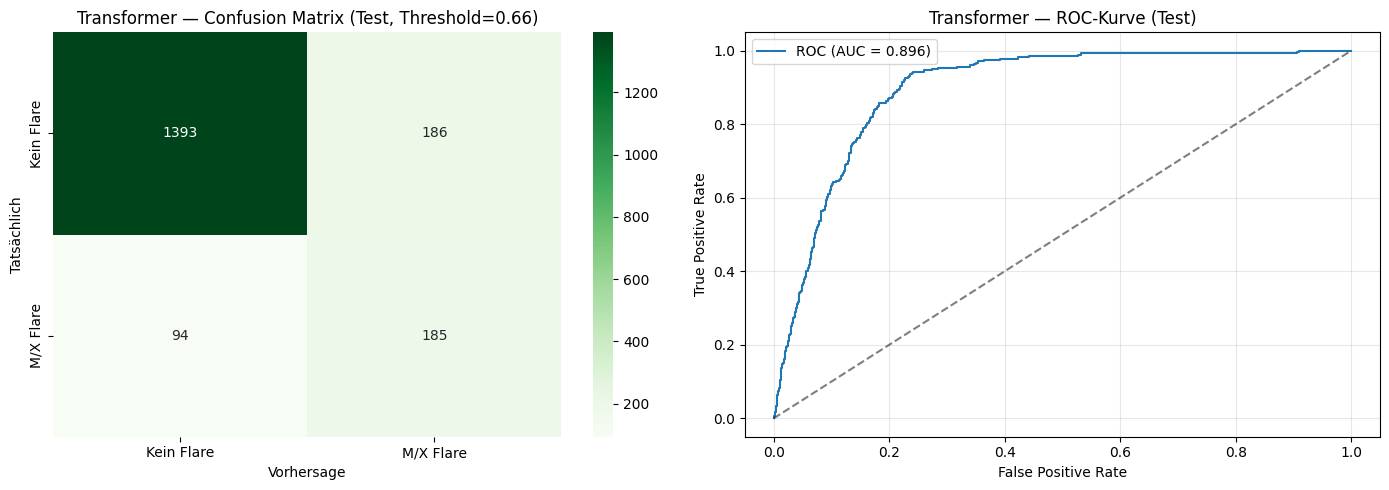

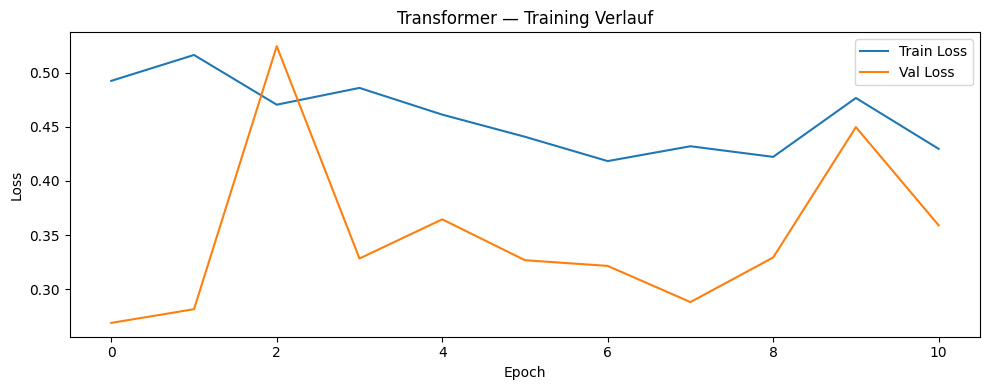

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'], ax=axes[0])
axes[0].set_xlabel('Vorhersage')
axes[0].set_ylabel('Tatsächlich')
axes[0].set_title(f'Transformer — Confusion Matrix (Test, Threshold={tf_best_threshold:.2f})')

tf_fpr, tf_tpr, _ = roc_curve(tf_all_labels, tf_all_probs)
axes[1].plot(tf_fpr, tf_tpr, label=f'ROC (AUC = {tf_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Transformer — ROC-Kurve (Test)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tf_train_losses, label='Train Loss')
plt.plot(tf_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer — Training Verlauf')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
lstm_results = {
    'accuracy': 100 * np.mean(all_preds == all_labels),
    'recall': recall,
    'f1': f1,
    'auc': roc_auc,
    'tss': tss,
    'hss': hss,
    'labels': all_labels,
    'predictions': all_preds,
    'probabilities': all_probs,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_f1s': train_f1s,
    'val_f1s': val_f1s,
}

gru_results = {
    'accuracy': 100 * np.mean(gru_all_preds == gru_all_labels),
    'recall': gru_recall,
    'f1': gru_f1,
    'auc': gru_roc_auc,
    'tss': gru_tss,
    'hss': gru_hss,
    'labels': gru_all_labels,
    'predictions': gru_all_preds,
    'probabilities': gru_all_probs,
    'train_losses': gru_train_losses,
    'val_losses': gru_val_losses,
    'train_f1s': gru_train_f1s,
    'val_f1s': gru_val_f1s,
}

transformer_results = {
    'accuracy': 100 * np.mean(tf_all_preds == tf_all_labels),
    'recall': tf_recall,
    'f1': tf_f1,
    'auc': tf_roc_auc,
    'tss': tf_tss,
    'hss': tf_hss,
    'labels': tf_all_labels,
    'predictions': tf_all_preds,
    'probabilities': tf_all_probs,
    'train_losses': tf_train_losses,
    'val_losses': tf_val_losses,
    'train_f1s': tf_train_f1s,
    'val_f1s': tf_val_f1s,
}

comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy (%)', 'Recall (M/X)', 'F1-Score', 'AUC-ROC', 'TSS', 'HSS', 'Parameter'],
    'LSTM': [
        f"{lstm_results['accuracy']:.1f}",
        f"{lstm_results['recall']:.3f}",
        f"{lstm_results['f1']:.3f}",
        f"{lstm_results['auc']:.3f}",
        f"{lstm_results['tss']:.3f}",
        f"{lstm_results['hss']:.3f}",
        f"{sum(p.numel() for p in model.parameters()):,}"
    ],
    'GRU': [
        f"{gru_results['accuracy']:.1f}",
        f"{gru_results['recall']:.3f}",
        f"{gru_results['f1']:.3f}",
        f"{gru_results['auc']:.3f}",
        f"{gru_results['tss']:.3f}",
        f"{gru_results['hss']:.3f}",
        f"{sum(p.numel() for p in gru_model.parameters()):,}"
    ],
    'Transformer': [
        f"{transformer_results['accuracy']:.1f}",
        f"{transformer_results['recall']:.3f}",
        f"{transformer_results['f1']:.3f}",
        f"{transformer_results['auc']:.3f}",
        f"{transformer_results['tss']:.3f}",
        f"{transformer_results['hss']:.3f}",
        f"{sum(p.numel() for p in transformer_model.parameters()):,}"
    ]
})

def highlight_better(row):
    models = ['LSTM', 'GRU', 'Transformer']
    vals = {m: float(row[m].replace(',', '')) for m in models}
    if row['Metrik'] == 'Parameter':
        best = min(vals, key=vals.get)
    else:
        best = max(vals, key=vals.get)
    row['Besser'] = best
    return row

comparison_df = comparison_df.apply(highlight_better, axis=1)

print("=" * 80)
print("           MODELLVERGLEICH: LSTM vs. GRU vs. Transformer")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

for m in ['LSTM', 'GRU', 'Transformer']:
    wins = (comparison_df['Besser'] == m).sum()
    print(f"{m} gewinnt {wins} von {len(comparison_df)} Metriken")

           MODELLVERGLEICH: LSTM vs. GRU vs. Transformer
      Metrik   LSTM    GRU Transformer      Besser
Accuracy (%)   84.3   85.1        84.9         GRU
Recall (M/X)  0.384  0.233       0.663 Transformer
    F1-Score  0.423  0.320       0.569 Transformer
     AUC-ROC  0.866  0.816       0.896 Transformer
         TSS  0.308  0.194       0.545 Transformer
         HSS  0.333  0.250       0.480 Transformer
   Parameter 89,345 68,097     406,913         GRU
LSTM gewinnt 0 von 7 Metriken
GRU gewinnt 2 von 7 Metriken
Transformer gewinnt 5 von 7 Metriken


### Visueller Vergleich der drei Modelle

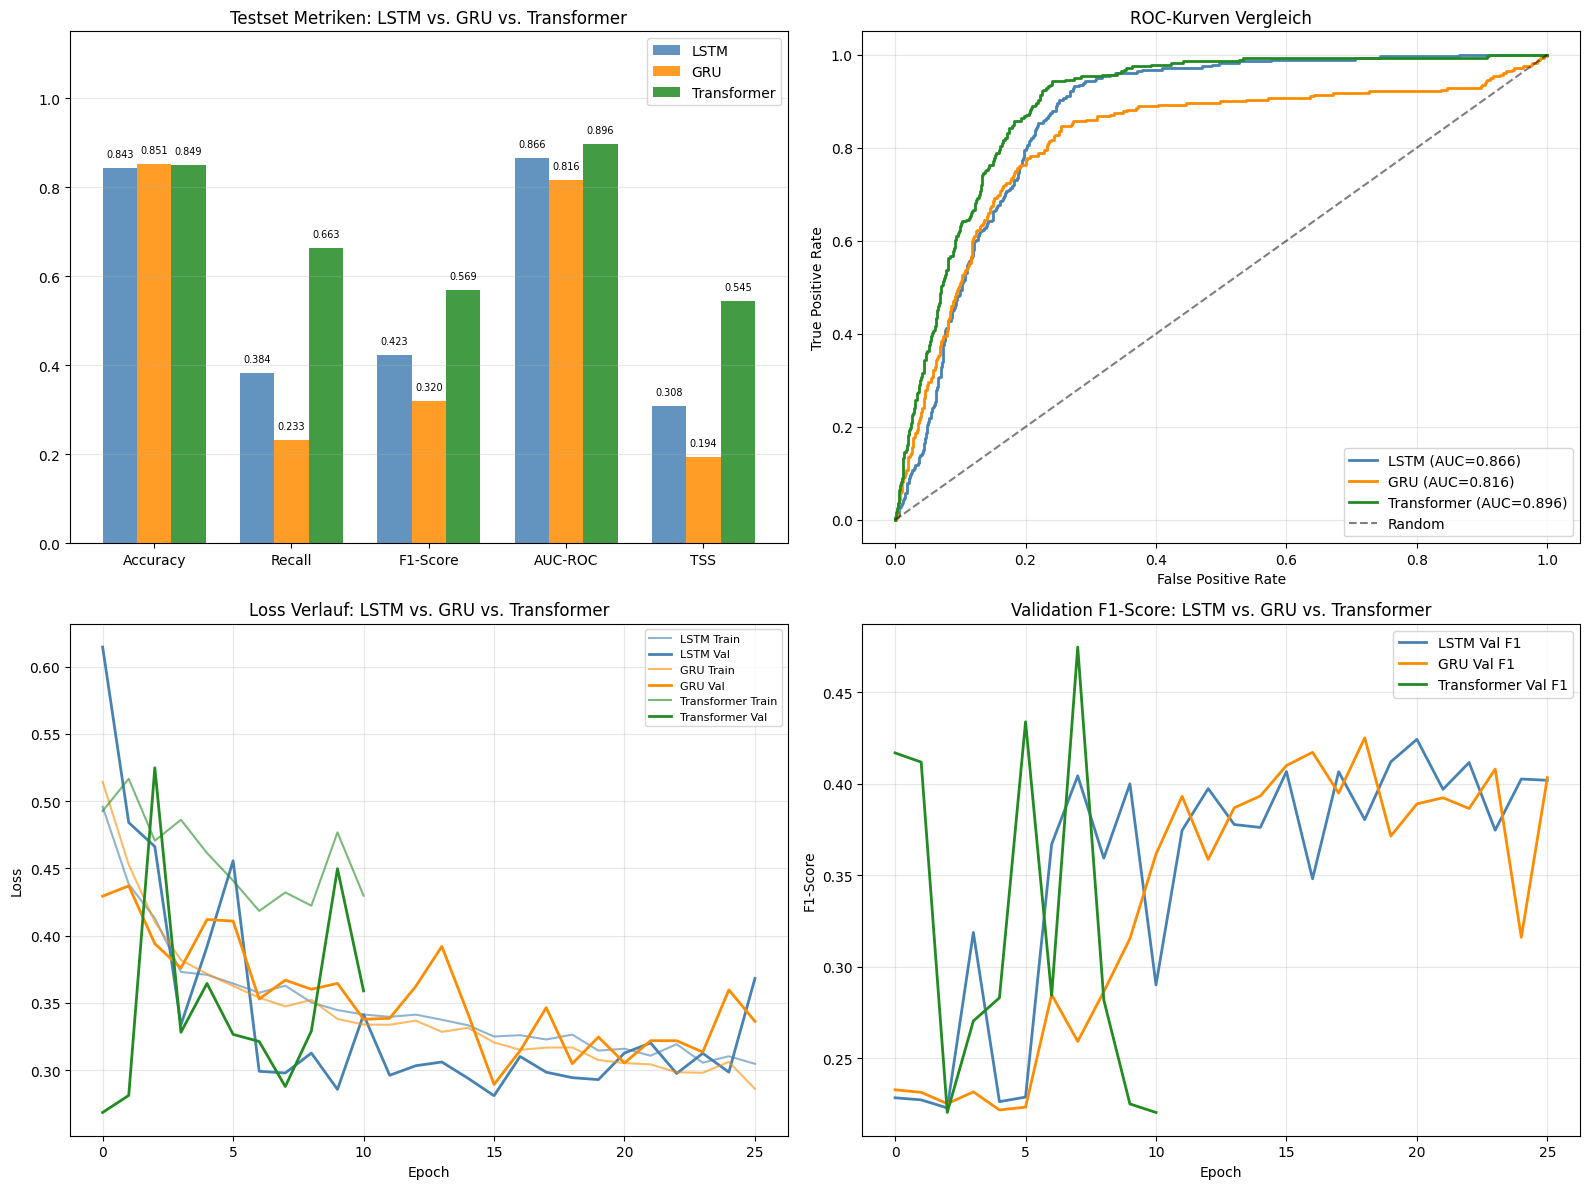

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC', 'TSS']
lstm_vals = [lstm_results['accuracy'] / 100, lstm_results['recall'], lstm_results['f1'], lstm_results['auc'], float(lstm_results['tss'])]
gru_vals = [gru_results['accuracy'] / 100, gru_results['recall'], gru_results['f1'], gru_results['auc'], float(gru_results['tss'])]
tf_vals = [transformer_results['accuracy'] / 100, transformer_results['recall'], transformer_results['f1'], transformer_results['auc'], float(transformer_results['tss'])]

x = np.arange(len(metrics))
width = 0.25
bars1 = axes[0, 0].bar(x - width, lstm_vals, width, label='LSTM', color='steelblue', alpha=0.85)
bars2 = axes[0, 0].bar(x, gru_vals, width, label='GRU', color='darkorange', alpha=0.85)
bars3 = axes[0, 0].bar(x + width, tf_vals, width, label='Transformer', color='forestgreen', alpha=0.85)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].set_title('Testset Metriken: LSTM vs. GRU vs. Transformer')
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                         f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

fpr_lstm, tpr_lstm, _ = roc_curve(lstm_results['labels'], lstm_results['probabilities'])
fpr_gru, tpr_gru, _ = roc_curve(gru_results['labels'], gru_results['probabilities'])
fpr_tf, tpr_tf, _ = roc_curve(transformer_results['labels'], transformer_results['probabilities'])

axes[0, 1].plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={lstm_results['auc']:.3f})", color='steelblue', linewidth=2)
axes[0, 1].plot(fpr_gru, tpr_gru, label=f"GRU (AUC={gru_results['auc']:.3f})", color='darkorange', linewidth=2)
axes[0, 1].plot(fpr_tf, tpr_tf, label=f"Transformer (AUC={transformer_results['auc']:.3f})", color='forestgreen', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0, 1].set_title('ROC-Kurven Vergleich')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(lstm_results['train_losses'], label='LSTM Train', color='steelblue', alpha=0.6)
axes[1, 0].plot(lstm_results['val_losses'], label='LSTM Val', color='steelblue', linewidth=2)
axes[1, 0].plot(gru_results['train_losses'], label='GRU Train', color='darkorange', alpha=0.6)
axes[1, 0].plot(gru_results['val_losses'], label='GRU Val', color='darkorange', linewidth=2)
axes[1, 0].plot(transformer_results['train_losses'], label='Transformer Train', color='forestgreen', alpha=0.6)
axes[1, 0].plot(transformer_results['val_losses'], label='Transformer Val', color='forestgreen', linewidth=2)
axes[1, 0].set_title('Loss Verlauf: LSTM vs. GRU vs. Transformer')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(lstm_results['val_f1s'], label='LSTM Val F1', color='steelblue', linewidth=2)
axes[1, 1].plot(gru_results['val_f1s'], label='GRU Val F1', color='darkorange', linewidth=2)
axes[1, 1].plot(transformer_results['val_f1s'], label='Transformer Val F1', color='forestgreen', linewidth=2)
axes[1, 1].set_title('Validation F1-Score: LSTM vs. GRU vs. Transformer')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

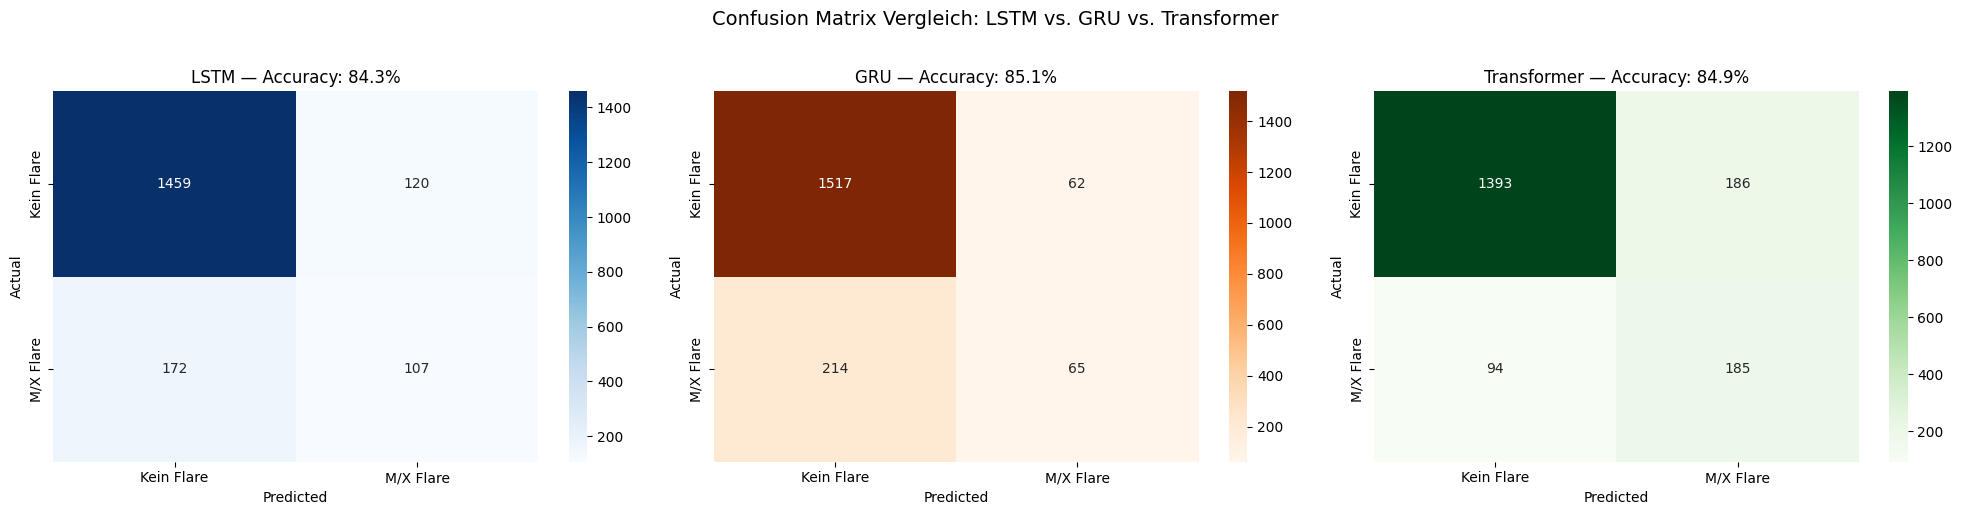

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_lstm = confusion_matrix(lstm_results['labels'], lstm_results['predictions'])
cm_gru = confusion_matrix(gru_results['labels'], gru_results['predictions'])
cm_tf = confusion_matrix(transformer_results['labels'], transformer_results['predictions'])

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'])
axes[0].set_title(f"LSTM — Accuracy: {lstm_results['accuracy']:.1f}%")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'])
axes[1].set_title(f"GRU — Accuracy: {gru_results['accuracy']:.1f}%")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Kein Flare', 'M/X Flare'],
            yticklabels=['Kein Flare', 'M/X Flare'])
axes[2].set_title(f"Transformer — Accuracy: {transformer_results['accuracy']:.1f}%")
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Vergleich: LSTM vs. GRU vs. Transformer', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()